# Bayesian Statistics

Bayesian statistics treats probability as a **degree of belief** that updates as evidence accumulates, via Bayes' theorem:

$$P(\theta | \text{data}) = \frac{P(\text{data}|\theta)\, P(\theta)}{P(\text{data})}$$

| Term | Name | Meaning |
|------|------|--------|
| $P(\theta)$ | **Prior** | Belief about $\theta$ before seeing data |
| $P(\text{data}\|\theta)$ | **Likelihood** | How probable the data is under $\theta$ |
| $P(\theta\|\text{data})$ | **Posterior** | Updated belief after seeing data |
| $P(\text{data})$ | Evidence | Normalising constant |

## Beta-Binomial Conjugate Model

For a coin-flip proportion $p$, the **conjugate prior** is $\text{Beta}(\alpha, \beta)$.
After observing $k$ heads in $n$ flips, the posterior is analytically:
$$p | \text{data} \sim \text{Beta}(\alpha + k,\ \beta + n - k)$$

This makes updating trivial — no numerical integration needed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(seed=42)

# Prior: Beta(2, 2) — weakly informative, centred at 0.5
alpha_prior, beta_prior = 2, 2
true_p = 0.65

# Simulate flipping a biased coin 50 times
n_flips = 50
outcomes = rng.binomial(1, true_p, size=n_flips)
k_heads  = outcomes.sum()

# Posterior update
alpha_post = alpha_prior + k_heads
beta_post  = beta_prior  + (n_flips - k_heads)

print(f'True p          : {true_p}')
print(f'Flips / Heads   : {n_flips} / {k_heads}')
print(f'Prior           : Beta({alpha_prior}, {beta_prior})  (mean={alpha_prior/(alpha_prior+beta_prior):.2f})')
print(f'Posterior       : Beta({alpha_post}, {beta_post})  (mean={alpha_post/(alpha_post+beta_post):.4f})')

# 95% Bayesian Credible Interval
cred_lo, cred_hi = stats.beta.ppf([0.025, 0.975], a=alpha_post, b=beta_post)
print(f'95% Credible Interval: ({cred_lo:.4f}, {cred_hi:.4f})')
print()

# Compare with frequentist 95% CI (Wilson)
p_hat   = k_heads / n_flips
z_star  = stats.norm.ppf(0.975)
freq_lo = p_hat - z_star * np.sqrt(p_hat*(1-p_hat)/n_flips)
freq_hi = p_hat + z_star * np.sqrt(p_hat*(1-p_hat)/n_flips)
print(f'Frequentist 95% CI (Wald): ({freq_lo:.4f}, {freq_hi:.4f})')
print()
print('Bayesian CI: range of p values with 95% posterior probability')
print('Frequentist CI: if we repeated the experiment, 95% of such CIs would contain true p')


True p          : 0.65
Flips / Heads   : 50 / 28
Prior           : Beta(2, 2)  (mean=0.50)
Posterior       : Beta(30, 24)  (mean=0.5556)
95% Credible Interval: (0.4228, 0.6844)

Frequentist 95% CI (Wald): (0.4224, 0.6976)

Bayesian CI: range of p values with 95% posterior probability
Frequentist CI: if we repeated the experiment, 95% of such CIs would contain true p


## Prior, Likelihood, and Posterior — Visualisation

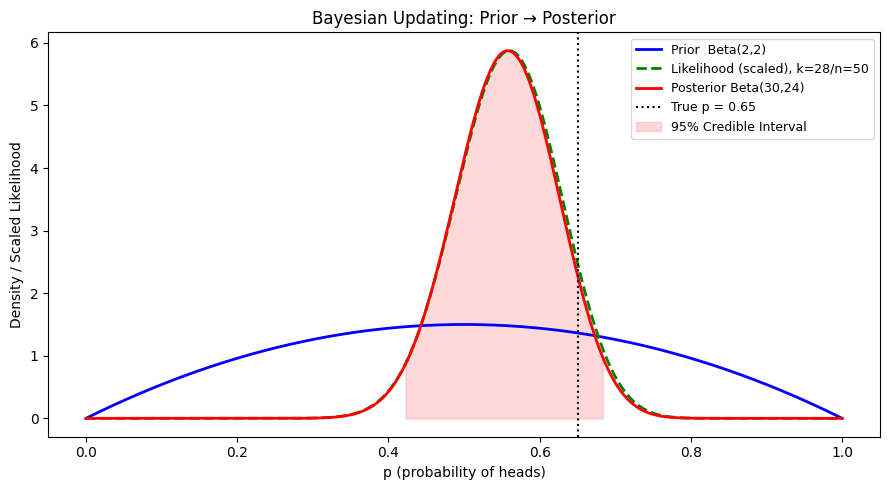

In [2]:
p_vals = np.linspace(0, 1, 500)

prior_pdf     = stats.beta.pdf(p_vals, alpha_prior, beta_prior)
likelihood    = stats.binom.pmf(k_heads, n_flips, p_vals)  # proportional to likelihood
likelihood   /= likelihood.max()   # normalise for display
posterior_pdf = stats.beta.pdf(p_vals, alpha_post, beta_post)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(p_vals, prior_pdf,     'b-',  lw=2, label=f'Prior  Beta({alpha_prior},{beta_prior})')
ax.plot(p_vals, likelihood * max(prior_pdf.max(), posterior_pdf.max()),
        'g--', lw=2, label=f'Likelihood (scaled), k={k_heads}/n={n_flips}')
ax.plot(p_vals, posterior_pdf, 'r-',  lw=2, label=f'Posterior Beta({alpha_post},{beta_post})')
ax.axvline(true_p, color='black', ls=':', lw=1.5, label=f'True p = {true_p}')
ax.fill_between(p_vals, posterior_pdf,
                where=(p_vals >= cred_lo) & (p_vals <= cred_hi),
                alpha=0.15, color='red', label='95% Credible Interval')
ax.set_xlabel('p (probability of heads)')
ax.set_ylabel('Density / Scaled Likelihood')
ax.set_title('Bayesian Updating: Prior → Posterior')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Sequential Bayesian Updating

One of the most powerful properties of Bayesian inference: the posterior after $n$ observations becomes the **prior** for the $(n+1)$-th observation. The order of data doesn't matter — only the total counts.

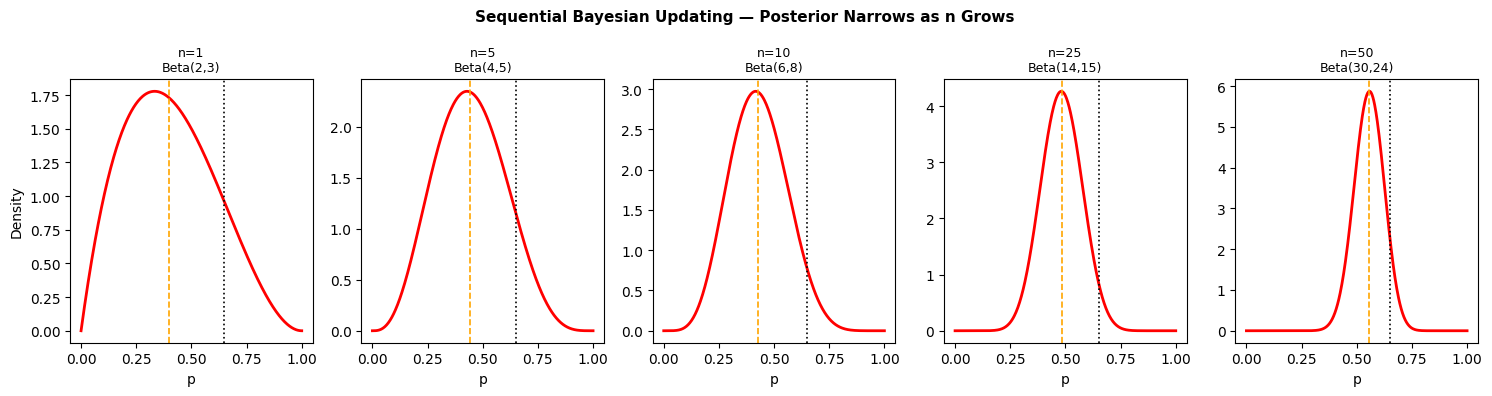

In [3]:
checkpoints = [1, 5, 10, 25, 50]
fig, axes   = plt.subplots(1, len(checkpoints), figsize=(15, 4), sharey=False)

a_cur, b_cur = alpha_prior, beta_prior
obs_so_far   = 0

for ax, cp in zip(axes, checkpoints):
    new_flips = outcomes[obs_so_far:cp]
    a_cur    += new_flips.sum()
    b_cur    += len(new_flips) - new_flips.sum()
    obs_so_far = cp

    post_mean = a_cur / (a_cur + b_cur)
    ax.plot(p_vals, stats.beta.pdf(p_vals, a_cur, b_cur), 'r-', lw=2)
    ax.axvline(true_p,    color='black', ls=':', lw=1.2, label='True p')
    ax.axvline(post_mean, color='orange', ls='--', lw=1.2, label=f'Post. mean={post_mean:.2f}')
    ax.set_title(f'n={cp}\nBeta({a_cur},{b_cur})', fontsize=9)
    ax.set_xlabel('p')
    if ax == axes[0]:
        ax.set_ylabel('Density')

plt.suptitle('Sequential Bayesian Updating — Posterior Narrows as n Grows', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


---
## ML/AI Connection

- **L2 regularisation (Ridge)** is MAP estimation with a Gaussian prior on the weights: maximising $P(w|\text{data}) \propto P(\text{data}|w)\,P(w)$ with $P(w) = \mathcal{N}(0,\sigma^2)$ gives the Ridge penalty.
- **L1 regularisation (Lasso)** corresponds to a Laplace prior on the weights.
- **Bayesian hyperparameter optimisation** (Optuna, BoHB) maintains a posterior over the performance surface and samples the next hyperparameter set from the most promising region.
- **Uncertainty quantification:** Bayesian deep learning produces a posterior predictive distribution — giving not just a point prediction but a confidence range.
